NIFTY observations: 433

SELECTED CONTRACT
Underlying: NIFTY
Option: CE
Reference Date: 2026-03-30
Reference NIFTY: 22331.4
Selected Strike: 22350
Expiry: 30-Jun-2026

Progress: 0/390
Progress: 25/390
Progress: 50/390
Progress: 75/390
Progress: 100/390
Progress: 125/390
Progress: 150/390
Progress: 175/390
Progress: 200/390
Progress: 225/390
Progress: 250/390
Progress: 275/390
Progress: 300/390
Progress: 325/390
Progress: 350/390
Progress: 375/390

Historical option observations: 60

Calculating contract IV...

Running rolling EGARCH...


/tmp/ipykernel_6580/3556709244.py:680: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  result = model.fit(



FINAL OBSERVATIONS: 25


,Date,Option_Close,Underlying,Days_To_Expiry,IV_pct,EGARCH_pct,Future_Realized_Vol,IV_EGARCH_Spread,IV_RV_Spread
0,2026-04-01,945.95,22679.40,90,7.8899,2.0261,18.1489,5.8638,-10.2590
1,2026-04-02,1279.00,22713.10,89,16.9460,1.8202,18.4392,15.1257,-1.4933
2,2026-04-06,1538.45,22968.25,85,19.8467,1.7333,18.2468,18.1134,1.5999
3,2026-04-07,1538.45,23123.65,84,16.8312,1.5508,18.4429,15.2804,-1.6117
4,2026-04-20,2446.90,24364.85,71,9.3088,1.2917,13.4547,8.0171,-4.1459
5,2026-04-22,2446.90,24378.10,69,7.9889,1.0099,12.8405,6.9789,-4.8516
6,2026-04-23,2271.25,24173.05,68,14.3367,1.0358,13.4888,13.3009,0.8479
7,2026-04-24,2271.25,23897.95,67,25.7109,0.9564,12.9928,24.7545,12.7181
8,2026-04-27,2271.25,24092.70,64,20.4498,0.9503,12.6556,19.4996,7.7942
9,2026-04-28,2271.25,23995.70,63,24.2813,0.8804,13.5990,23.4009,10.6823


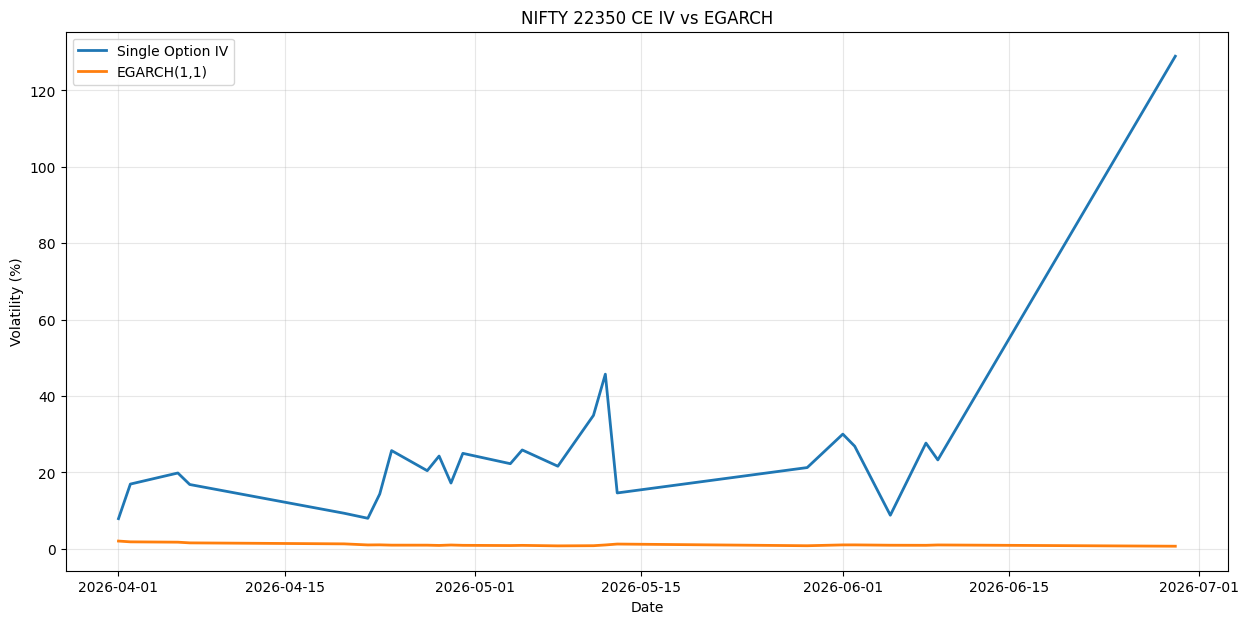

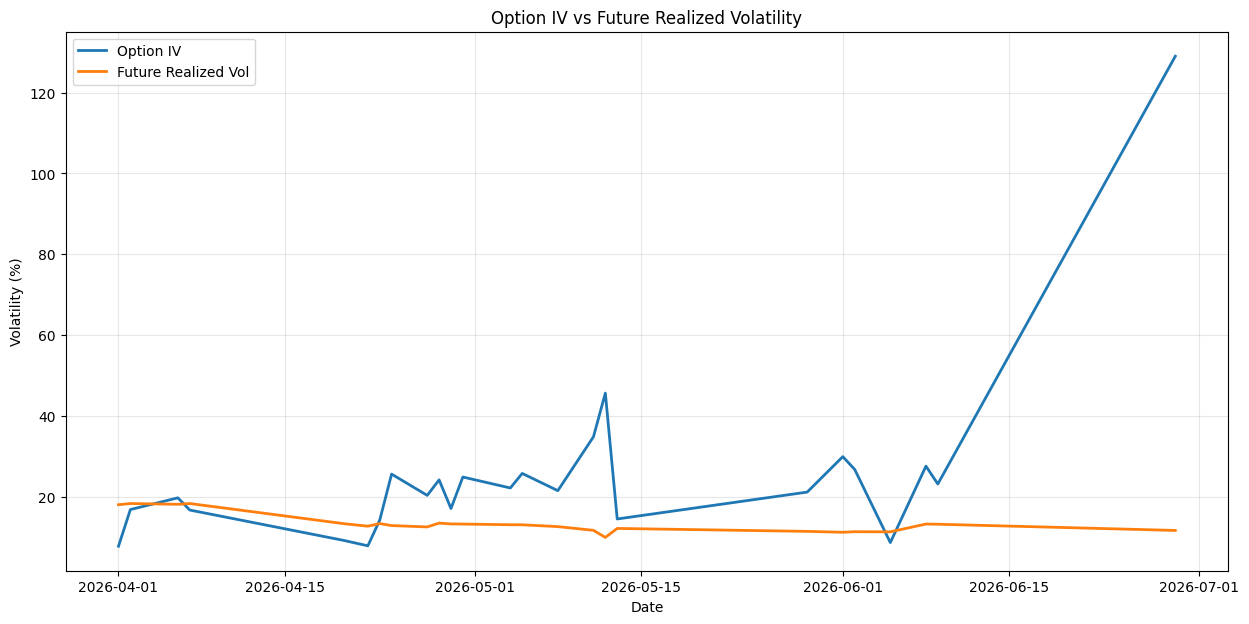

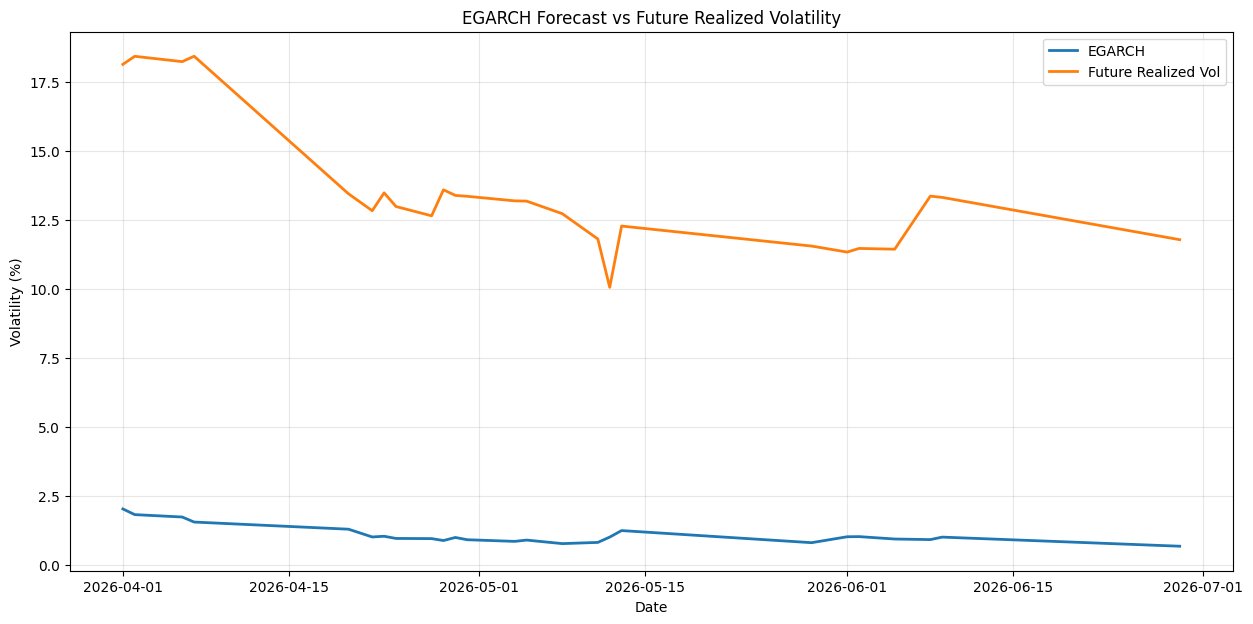

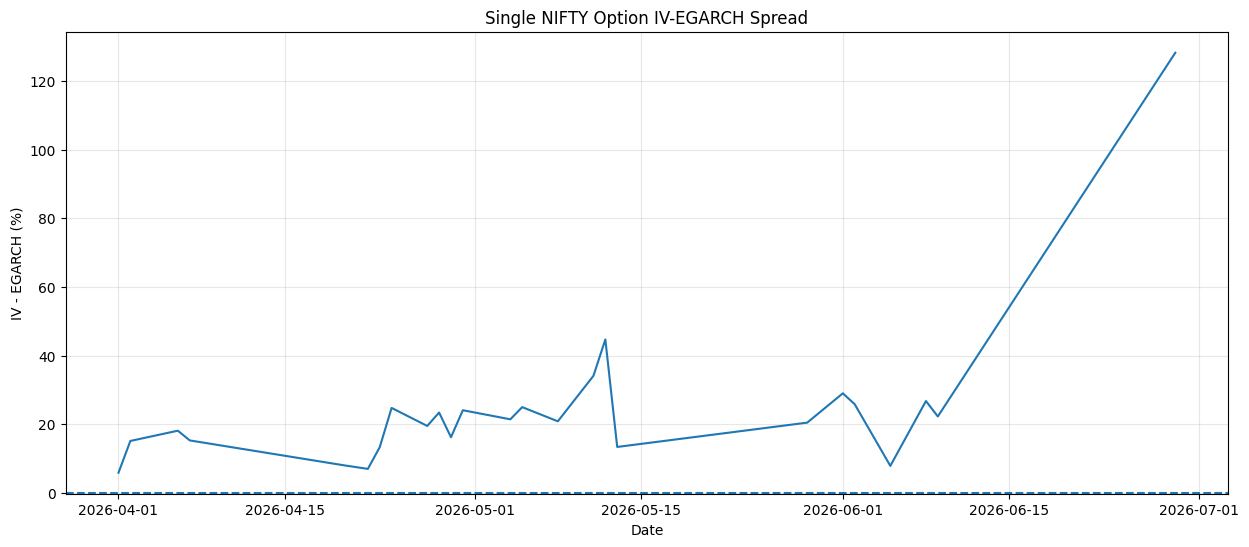


FORECAST COMPARISON


,Model,RMSE,MAE
0,Single NIFTY Option IV,26.4534,14.0428
1,"EGARCH(1,1)",12.5441,12.3819



IV vs Future Realized Vol: -0.3005
EGARCH vs Future Realized Vol: 0.8499

IV PREMIUM
Average Option IV: 25.51
Average EGARCH: 1.08
Average Future RV: 13.47
Average IV-EGARCH: 24.42
Average IV-RV: 12.04

Files saved:
NIFTY_Single_Option_IV_EGARCH.csv
NIFTY_Single_Option_IV_EGARCH_Comparison.csv

PROJECT COMPLETE
NIFTY 22350 CE
Expiry: 30-Jun-2026
✓ Single Option Contract
✓ Historical Option Prices
✓ Black-Scholes Implied Volatility
✓ Rolling EGARCH(1,1)
✓ Future Realized Volatility
✓ IV vs EGARCH
✓ IV-EGARCH Spread
✓ IV-RV Spread
✓ RMSE
✓ MAE
✓ Correlation
✓ CSV Export


In [ ]:
# ============================================================
# NIFTY SINGLE OPTION IV vs EGARCH
# CORRECTED HISTORICAL CONTRACT VERSION
# ============================================================

!pip -q install curl_cffi yfinance arch pandas numpy scipy matplotlib scikit-learn

import io
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

# ============================================================
# PARAMETERS
# ============================================================

START_DATE = "2025-01-01"

# Use a historical expired contract
# so that sufficient future realized volatility
# observations exist.

SELECTED_EXPIRY = "30-Jun-2026"

# Approximately ATM strike will be selected
# automatically using NIFTY price around the
# beginning of the contract's observation period.

RISK_FREE_RATE = 0.10

# Reduced from 500 because our sample is shorter
EGARCH_WINDOW = 250

# Future realized volatility horizon
RV_HORIZON = 21

# ============================================================
# 1. NIFTY DATA
# ============================================================

print("Downloading NIFTY data...")

nifty = yf.download(
    "^NSEI",
    start=START_DATE,
    end="2026-10-01",
    auto_adjust=True,
    progress=False
)

if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

nifty = nifty[["Close"]].dropna()

nifty.columns = ["NIFTY"]

print(
    "NIFTY observations:",
    len(nifty)
)

# ============================================================
# 2. SELECT ATM STRIKE
# ============================================================

# Use NIFTY price approximately 60 trading days
# before expiry.

expiry_dt = pd.Timestamp(
    SELECTED_EXPIRY
)

candidate_dates = nifty.index[
    nifty.index < expiry_dt
]

if len(candidate_dates) < 60:

    raise Exception(
        "Not enough NIFTY history before expiry."
    )

reference_date = candidate_dates[-60]

reference_spot = float(
    nifty.loc[
        reference_date,
        "NIFTY"
    ]
)

# NIFTY strike interval = 50
selected_strike = (
    round(
        reference_spot / 50
    )
    * 50
)

print(
    "\n======================================"
)

print(
    "SELECTED CONTRACT"
)

print(
    "======================================"
)

print(
    "Underlying: NIFTY"
)

print(
    "Option: CE"
)

print(
    "Reference Date:",
    reference_date.date()
)

print(
    "Reference NIFTY:",
    round(
        reference_spot,
        2
    )
)

print(
    "Selected Strike:",
    selected_strike
)

print(
    "Expiry:",
    SELECTED_EXPIRY
)

# ============================================================
# 3. NSE SESSION
# ============================================================

from curl_cffi import requests

session = requests.Session(
    impersonate="chrome"
)

session.headers.update({

    "Accept":
        "application/json, text/plain, */*",

    "Accept-Language":
        "en-US,en;q=0.9",

    "Referer":
        "https://www.nseindia.com/option-chain",

    "User-Agent":
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/128.0.0.0 Safari/537.36"
})

session.get(
    "https://www.nseindia.com/option-chain",
    timeout=20
)

# ============================================================
# 4. BHAVCOPY DOWNLOAD FUNCTION
# ============================================================

def download_bhavcopy(date):

    yyyymmdd = date.strftime(
        "%Y%m%d"
    )

    url = (
        "https://nsearchives.nseindia.com/"
        "content/fo/"
        f"BhavCopy_NSE_FO_0_0_0_"
        f"{yyyymmdd}_F_0000.csv.zip"
    )

    try:

        response = session.get(
            url,
            timeout=20
        )

        if response.status_code != 200:
            return None

        z = zipfile.ZipFile(
            io.BytesIO(
                response.content
            )
        )

        csv_name = z.namelist()[0]

        df = pd.read_csv(
            z.open(csv_name)
        )

        return df

    except:

        return None


# ============================================================
# 5. DOWNLOAD HISTORICAL OPTION DATA
# ============================================================

print(
    "\nDownloading historical option data..."
)

start = pd.Timestamp(
    START_DATE
)

end = min(
    pd.Timestamp.today(),
    expiry_dt
)

dates = pd.bdate_range(
    start,
    end
)

option_rows = []

for i, date in enumerate(
    dates
):

    if i % 25 == 0:

        print(
            f"Progress: "
            f"{i}/{len(dates)}"
        )

    df_day = download_bhavcopy(
        date.to_pydatetime()
    )

    if df_day is None:
        continue

    df_day.columns = [
        str(c).strip()
        for c in df_day.columns
    ]

    required = [
        "TckrSymb",
        "XpryDt",
        "StrkPric",
        "OptnTp"
    ]

    if not all(
        c in df_day.columns
        for c in required
    ):
        continue

    temp = df_day[
        (
            df_day["TckrSymb"]
            .astype(str)
            .str.upper()
            == "NIFTY"
        )
        &
        (
            df_day["OptnTp"]
            .astype(str)
            .str.upper()
            == "CE"
        )
    ].copy()

    if temp.empty:
        continue

    temp["XpryDt"] = pd.to_datetime(
        temp["XpryDt"],
        errors="coerce"
    )

    temp["StrkPric"] = pd.to_numeric(
        temp["StrkPric"],
        errors="coerce"
    )

    temp = temp[
        (
            temp["XpryDt"].dt.date
            ==
            expiry_dt.date()
        )
        &
        (
            np.isclose(
                temp["StrkPric"],
                selected_strike
            )
        )
    ]

    if temp.empty:
        continue

    row = temp.iloc[0]

    # Find closing price column

    close_col = None

    for c in [
        "ClsPric",
        "LastPric"
    ]:

        if c in temp.columns:

            close_col = c
            break

    if close_col is None:
        continue

    option_close = pd.to_numeric(
        row[close_col],
        errors="coerce"
    )

    if pd.isna(option_close):
        continue

    # Underlying price

    underlying = np.nan

    for c in [
        "UndrlygPric",
        "UndrlygVal"
    ]:

        if c in temp.columns:

            underlying = pd.to_numeric(
                row[c],
                errors="coerce"
            )

            if not pd.isna(
                underlying
            ):
                break

    option_rows.append({

        "Date":
            pd.Timestamp(date),

        "Option_Close":
            float(option_close),

        "Underlying":
            underlying,

        "Strike":
            selected_strike,

        "Expiry":
            expiry_dt
    })


option_data = pd.DataFrame(
    option_rows
)

if option_data.empty:

    raise Exception(
        "No historical observations found."
    )

option_data = (
    option_data
    .drop_duplicates("Date")
    .sort_values("Date")
)

print(
    "\nHistorical option observations:",
    len(option_data)
)

# ============================================================
# 6. MERGE NIFTY PRICE
# ============================================================

nifty_reset = (
    nifty
    .reset_index()
)

nifty_reset.columns = [
    "Date",
    "NIFTY"
]

option_data = option_data.merge(
    nifty_reset,
    on="Date",
    how="left"
)

option_data["Underlying"] = (
    option_data["Underlying"]
    .fillna(
        option_data["NIFTY"]
    )
)

# ============================================================
# 7. TIME TO EXPIRY
# ============================================================

option_data["Days_To_Expiry"] = (

    option_data["Expiry"]
    -
    option_data["Date"]

).dt.days

option_data["T"] = (
    option_data["Days_To_Expiry"]
    / 365.0
)

option_data = option_data[
    option_data["T"] > 0
].copy()

# ============================================================
# 8. BLACK-SCHOLES CALL
# ============================================================

def bs_call(
    S,
    K,
    T,
    r,
    sigma
):

    if (
        S <= 0
        or K <= 0
        or T <= 0
        or sigma <= 0
    ):

        return np.nan

    d1 = (
        np.log(S / K)
        +
        (
            r
            +
            0.5 * sigma**2
        ) * T
    ) / (
        sigma * np.sqrt(T)
    )

    d2 = (
        d1
        -
        sigma * np.sqrt(T)
    )

    return (
        S * norm.cdf(d1)
        -
        K
        * np.exp(-r*T)
        * norm.cdf(d2)
    )


# ============================================================
# 9. IMPLIED VOLATILITY
# ============================================================

def solve_iv(
    price,
    S,
    K,
    T,
    r
):

    if (
        price <= 0
        or S <= 0
        or K <= 0
        or T <= 0
    ):
        return np.nan

    intrinsic = max(
        S
        -
        K * np.exp(-r*T),
        0
    )

    if price < intrinsic:
        return np.nan

    try:

        return brentq(

            lambda sigma:

                bs_call(
                    S,
                    K,
                    T,
                    r,
                    sigma
                )
                -
                price,

            0.0001,
            5.0

        )

    except:

        return np.nan


print(
    "\nCalculating contract IV..."
)

option_data["IV"] = option_data.apply(

    lambda row:

        solve_iv(

            row["Option_Close"],

            row["Underlying"],

            selected_strike,

            row["T"],

            RISK_FREE_RATE

        ),

    axis=1
)

option_data["IV_pct"] = (
    option_data["IV"] * 100
)

option_data = option_data.dropna(
    subset=["IV"]
)

# ============================================================
# 10. NIFTY RETURNS
# ============================================================

nifty_returns = (
    nifty["NIFTY"]
    .pct_change()
    .dropna()
    * 100
)

# ============================================================
# 11. ROLLING EGARCH
# ============================================================

print(
    "\nRunning rolling EGARCH..."
)

egarch_values = []

for date in option_data["Date"]:

    historical = (
        nifty_returns[
            nifty_returns.index < date
        ]
        .dropna()
    )

    if len(
        historical
    ) < EGARCH_WINDOW:

        egarch_values.append(
            np.nan
        )

        continue

    train = historical.iloc[
        -EGARCH_WINDOW:
    ]

    try:

        model = arch_model(

            train,

            mean="Zero",

            vol="EGARCH",

            p=1,

            o=1,

            q=1,

            dist="normal",

            rescale=False

        )

        result = model.fit(
            disp="off"
        )

        forecast = (
            result
            .forecast(
                horizon=1,
                reindex=False
            )
        )

        variance = (
            forecast
            .variance
            .iloc[-1, 0]
        )

        egarch_values.append(
            np.sqrt(variance)
        )

    except:

        egarch_values.append(
            np.nan
        )

option_data[
    "EGARCH_pct"
] = egarch_values

# ============================================================
# 12. FUTURE REALIZED VOLATILITY
# ============================================================

returns = (
    nifty["NIFTY"]
    .pct_change()
)

realized_vol = (
    returns
    .rolling(RV_HORIZON)
    .std()
    * np.sqrt(252)
    * 100
)

future_rv = (
    realized_vol
    .shift(-RV_HORIZON)
)

future_rv = (
    future_rv
    .rename(
        "Future_Realized_Vol"
    )
    .reset_index()
)

future_rv.columns = [
    "Date",
    "Future_Realized_Vol"
]

option_data = option_data.merge(
    future_rv,
    on="Date",
    how="left"
)

# ============================================================
# 13. SPREADS
# ============================================================

option_data[
    "IV_EGARCH_Spread"
] = (

    option_data["IV_pct"]
    -
    option_data["EGARCH_pct"]

)

option_data[
    "IV_RV_Spread"
] = (

    option_data["IV_pct"]
    -
    option_data[
        "Future_Realized_Vol"
    ]

)

# ============================================================
# 14. ANALYSIS DATASET
# ============================================================

analysis = option_data.dropna(
    subset=[
        "IV_pct",
        "EGARCH_pct",
        "Future_Realized_Vol"
    ]
).copy()

print(
    "\n======================================"
)

print(
    "FINAL OBSERVATIONS:",
    len(analysis)
)

print(
    "======================================"
)

if len(analysis) < 10:

    raise Exception(

        "Still too few observations. "
        "Choose an older expiry or reduce "
        "EGARCH_WINDOW."

    )

# ============================================================
# 15. DISPLAY DATA
# ============================================================

display(
    analysis[
        [
            "Date",
            "Option_Close",
            "Underlying",
            "Days_To_Expiry",
            "IV_pct",
            "EGARCH_pct",
            "Future_Realized_Vol",
            "IV_EGARCH_Spread",
            "IV_RV_Spread"
        ]
    ].round(4)
)

# ============================================================
# 16. IV vs EGARCH
# ============================================================

plt.figure(
    figsize=(15,7)
)

plt.plot(
    analysis["Date"],
    analysis["IV_pct"],
    label="Single Option IV",
    linewidth=2
)

plt.plot(
    analysis["Date"],
    analysis["EGARCH_pct"],
    label="EGARCH(1,1)",
    linewidth=2
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Volatility (%)"
)

plt.title(
    f"NIFTY {selected_strike} CE "
    f"IV vs EGARCH"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# 17. IV vs FUTURE REALIZED VOL
# ============================================================

plt.figure(
    figsize=(15,7)
)

plt.plot(
    analysis["Date"],
    analysis["IV_pct"],
    label="Option IV",
    linewidth=2
)

plt.plot(
    analysis["Date"],
    analysis[
        "Future_Realized_Vol"
    ],
    label="Future Realized Vol",
    linewidth=2
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Volatility (%)"
)

plt.title(
    "Option IV vs Future Realized Volatility"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# 18. EGARCH vs FUTURE REALIZED VOL
# ============================================================

plt.figure(
    figsize=(15,7)
)

plt.plot(
    analysis["Date"],
    analysis["EGARCH_pct"],
    label="EGARCH",
    linewidth=2
)

plt.plot(
    analysis["Date"],
    analysis[
        "Future_Realized_Vol"
    ],
    label="Future Realized Vol",
    linewidth=2
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Volatility (%)"
)

plt.title(
    "EGARCH Forecast vs Future Realized Volatility"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# 19. IV-EGARCH SPREAD
# ============================================================

plt.figure(
    figsize=(15,6)
)

plt.plot(
    analysis["Date"],
    analysis[
        "IV_EGARCH_Spread"
    ],
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "IV - EGARCH (%)"
)

plt.title(
    "Single NIFTY Option IV-EGARCH Spread"
)

plt.grid(
    alpha=0.3
)

plt.show()

# ============================================================
# 20. FORECAST ACCURACY
# ============================================================

iv_rmse = np.sqrt(
    mean_squared_error(

        analysis[
            "Future_Realized_Vol"
        ],

        analysis[
            "IV_pct"
        ]

    )
)

egarch_rmse = np.sqrt(
    mean_squared_error(

        analysis[
            "Future_Realized_Vol"
        ],

        analysis[
            "EGARCH_pct"
        ]

    )
)

iv_mae = mean_absolute_error(

    analysis[
        "Future_Realized_Vol"
    ],

    analysis[
        "IV_pct"
    ]

)

egarch_mae = mean_absolute_error(

    analysis[
        "Future_Realized_Vol"
    ],

    analysis[
        "EGARCH_pct"
    ]

)

comparison = pd.DataFrame({

    "Model": [

        "Single NIFTY Option IV",

        "EGARCH(1,1)"

    ],

    "RMSE": [

        iv_rmse,

        egarch_rmse

    ],

    "MAE": [

        iv_mae,

        egarch_mae

    ]

})

print(
    "\n======================================"
)

print(
    "FORECAST COMPARISON"
)

print(
    "======================================"
)

display(
    comparison.round(4)
)

# ============================================================
# 21. CORRELATION
# ============================================================

corr_iv = (
    analysis[
        [
            "IV_pct",
            "Future_Realized_Vol"
        ]
    ]
    .corr()
    .iloc[0,1]
)

corr_egarch = (
    analysis[
        [
            "EGARCH_pct",
            "Future_Realized_Vol"
        ]
    ]
    .corr()
    .iloc[0,1]
)

print(
    "\nIV vs Future Realized Vol:",
    round(corr_iv,4)
)

print(
    "EGARCH vs Future Realized Vol:",
    round(corr_egarch,4)
)

# ============================================================
# 22. IMPLIED VOLATILITY PREMIUM
# ============================================================

print(
    "\n======================================"
)

print(
    "IV PREMIUM"
)

print(
    "======================================"
)

print(
    "Average Option IV:",
    round(
        analysis[
            "IV_pct"
        ].mean(),
        2
    )
)

print(
    "Average EGARCH:",
    round(
        analysis[
            "EGARCH_pct"
        ].mean(),
        2
    )
)

print(
    "Average Future RV:",
    round(
        analysis[
            "Future_Realized_Vol"
        ].mean(),
        2
    )
)

print(
    "Average IV-EGARCH:",
    round(
        analysis[
            "IV_EGARCH_Spread"
        ].mean(),
        2
    )
)

print(
    "Average IV-RV:",
    round(
        analysis[
            "IV_RV_Spread"
        ].mean(),
        2
    )
)

# ============================================================
# 23. EXPORT
# ============================================================

analysis.to_csv(
    "NIFTY_Single_Option_IV_EGARCH.csv",
    index=False
)

comparison.to_csv(
    "NIFTY_Single_Option_IV_EGARCH_Comparison.csv",
    index=False
)

print(
    "\nFiles saved:"
)

print(
    "NIFTY_Single_Option_IV_EGARCH.csv"
)

print(
    "NIFTY_Single_Option_IV_EGARCH_Comparison.csv"
)

# ============================================================
# FINAL
# ============================================================

print(
    "\n=============================================="
)

print(
    "PROJECT COMPLETE"
)

print(
    "=============================================="
)

print(
    f"NIFTY {selected_strike} CE"
)

print(
    f"Expiry: {SELECTED_EXPIRY}"
)

print(
    "✓ Single Option Contract"
)

print(
    "✓ Historical Option Prices"
)

print(
    "✓ Black-Scholes Implied Volatility"
)

print(
    "✓ Rolling EGARCH(1,1)"
)

print(
    "✓ Future Realized Volatility"
)

print(
    "✓ IV vs EGARCH"
)

print(
    "✓ IV-EGARCH Spread"
)

print(
    "✓ IV-RV Spread"
)

print(
    "✓ RMSE"
)

print(
    "✓ MAE"
)

print(
    "✓ Correlation"
)

print(
    "✓ CSV Export"
)

print(
    "=============================================="
)